# Image classification with modern Vision Transformers




This notebook has been adapted based on an official [keras example](https://github.com/keras-team/keras-io/tree/master/examples/vision) of using vision transformers for image classification, and demonstrates it on the [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html).

![Figure 1 from Dosovitskiy *et al.* 2021 ViT architecture](images/ViT_architecture.png)

In particular, here we will use a much improved vision transformer, called Swin Transformer. Swin Transformer (**S**hifted **Win**dow Transformer) can serve as a
general-purpose backbone for computer vision. Swin Transformer is a hierarchical
Transformer whose representations are computed with _shifted windows_. The
shifted window scheme brings greater efficiency by limiting self-attention
computation to non-overlapping local windows while also allowing for
cross-window connections. This architecture has the flexibility to model
information at various scales and has a linear computational complexity with
respect to image size.

<div>
<img src="images/vit-swin.png" width="500"/>
</div>


## Import our packages

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
import matplotlib.pyplot as plt
import numpy as np
from keras import layers, ops

keras.utils.set_random_seed(42)
print("Keras:", keras.__version__, "| backend:", keras.backend.backend())

Keras: 3.8.0 | backend: torch


## Configure the hyperparameters

A key parameter to pick is the `patch_size`, the size of the input patches.
In order to use each pixel as an individual input, you can set `patch_size` to
`(1, 1)`. Below, we take inspiration from the original paper settings for
training on ImageNet-1K, keeping most of the original settings for this example.

In [2]:
num_classes = 100
input_shape = (32, 32, 3)

patch_size = (2, 2)
dropout_rate = 0.03
num_heads = 8
embed_dim = 64
num_mlp = 256
qkv_bias = True
window_size = 2
shift_size = 1
image_dimension = 32

num_patch_x = input_shape[0] // patch_size[0]
num_patch_y = input_shape[1] // patch_size[1]

learning_rate = 1e-3
batch_size = 256
num_epochs = 40
validation_split = 0.1
weight_decay = 1e-4
label_smoothing = 0.1

## Prepare the data

We then load the CIFAR-100 dataset using convenience functions within the `keras.datasets`,
normalize the images, and convert the integer labels to one-hot encoded vectors.

x_train shape: (45000, 32, 32, 3) - y_train shape: (45000, 100)
x_test shape: (10000, 32, 32, 3) - y_test shape: (10000, 100)


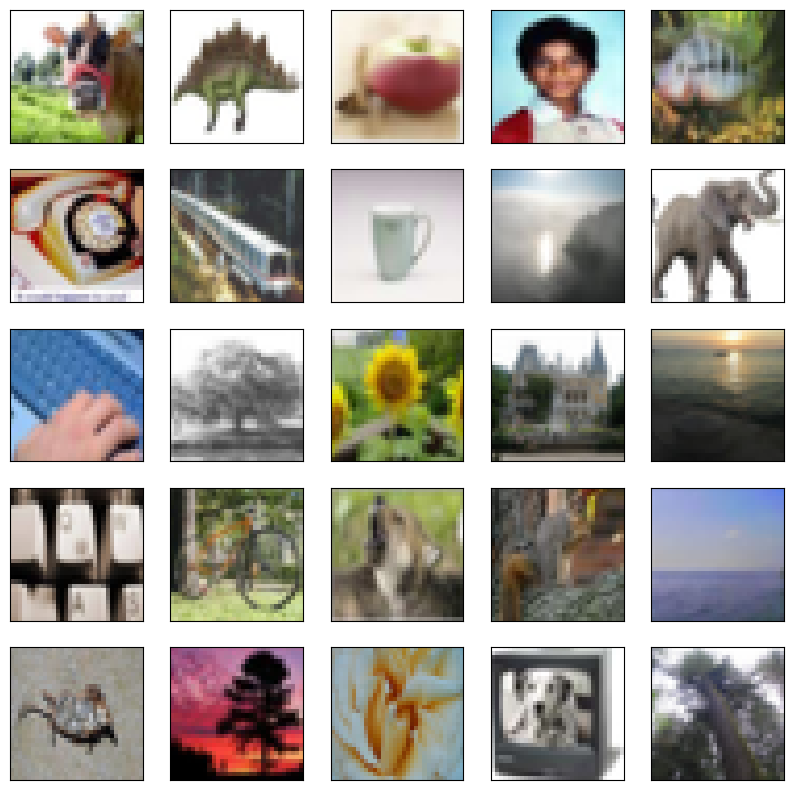

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

num_train_samples = int(len(x_train) * (1 - validation_split))
x_train, x_val = np.split(x_train, [num_train_samples])
y_train, y_val = np.split(y_train, [num_train_samples])

print(f"x_train shape: {x_train.shape} - y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape} - y_test shape: {y_test.shape}")

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
plt.show()

## Helper functions

We create two helper functions to help us get a sequence of
patches from the image.

In [4]:
@keras.saving.register_keras_serializable()
class WindowPartition(layers.Layer):
    def __init__(self, window_size, **kwargs):
        super().__init__(**kwargs)
        self.window_size = window_size

    def call(self, x):
        _, height, width, channels = x.shape
        patch_num_y = height // self.window_size
        patch_num_x = width // self.window_size
        x = ops.reshape(
            x,
            (-1, patch_num_y, self.window_size, patch_num_x, self.window_size, channels),
        )
        x = ops.transpose(x, (0, 1, 3, 2, 4, 5))
        return ops.reshape(x, (-1, self.window_size, self.window_size, channels))

    def get_config(self):
        return {"window_size": self.window_size, **super().get_config()}


@keras.saving.register_keras_serializable()
class WindowReverse(layers.Layer):
    def __init__(self, window_size, height, width, channels, **kwargs):
        super().__init__(**kwargs)
        self.window_size = window_size
        self.height = height
        self.width = width
        self.channels = channels

    def call(self, windows):
        patch_num_y = self.height // self.window_size
        patch_num_x = self.width // self.window_size
        x = ops.reshape(
            windows,
            (
                -1,
                patch_num_y,
                patch_num_x,
                self.window_size,
                self.window_size,
                self.channels,
            ),
        )
        x = ops.transpose(x, (0, 1, 3, 2, 4, 5))
        return ops.reshape(x, (-1, self.height, self.width, self.channels))

    def get_config(self):
        return {
            "window_size": self.window_size,
            "height": self.height,
            "width": self.width,
            "channels": self.channels,
            **super().get_config(),
        }


## Window based multi-head self-attention

Usually Transformers perform global self-attention, where the relationships
between a token and all other tokens are computed. The global computation leads
to quadratic complexity with respect to the number of tokens. Here, as the
[original paper](https://arxiv.org/abs/2103.14030) suggests, we compute
self-attention within local windows, in a non-overlapping manner. Global
self-attention leads to quadratic computational complexity in the number of
patches, whereas window-based self-attention leads to linear complexity and is
easily scalable.

In [5]:
@keras.saving.register_keras_serializable()
class WindowAttention(layers.Layer):
    def __init__(
        self,
        dim,
        window_size,
        num_heads,
        qkv_bias=True,
        dropout_rate=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads
        self.qkv_bias = qkv_bias
        self.dropout_rate = dropout_rate
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = layers.Dense(dim * 3, use_bias=qkv_bias)
        self.dropout = layers.Dropout(dropout_rate)
        self.proj = layers.Dense(dim)

        num_window_elements = (2 * self.window_size[0] - 1) * (2 * self.window_size[1] - 1)
        self.relative_position_bias_table = self.add_weight(
            shape=(num_window_elements, self.num_heads),
            initializer="zeros",
            trainable=True,
            name="relative_position_bias_table",
        )

        coords_h = np.arange(self.window_size[0])
        coords_w = np.arange(self.window_size[1])
        coords = np.stack(np.meshgrid(coords_h, coords_w, indexing="ij"))
        coords_flatten = coords.reshape(2, -1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.transpose([1, 2, 0])
        relative_coords[:, :, 0] += self.window_size[0] - 1
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        self.relative_position_index = ops.convert_to_tensor(
            relative_coords.sum(-1),
            dtype="int32",
        )

    def call(self, x, mask=None, training=False):
        _, size, channels = x.shape
        head_dim = channels // self.num_heads

        x_qkv = self.qkv(x)
        x_qkv = ops.reshape(x_qkv, (-1, size, 3, self.num_heads, head_dim))
        x_qkv = ops.transpose(x_qkv, (2, 0, 3, 1, 4))
        q = x_qkv[0]
        k = x_qkv[1]
        v = x_qkv[2]

        q = q * self.scale
        k = ops.transpose(k, (0, 1, 3, 2))
        attn = ops.matmul(q, k)

        num_window_elements = self.window_size[0] * self.window_size[1]
        flat_index = ops.reshape(self.relative_position_index, (-1,))
        relative_position_bias = ops.take(
            self.relative_position_bias_table,
            flat_index,
            axis=0,
        )
        relative_position_bias = ops.reshape(
            relative_position_bias,
            (num_window_elements, num_window_elements, -1),
        )
        relative_position_bias = ops.transpose(relative_position_bias, (2, 0, 1))
        attn = attn + ops.expand_dims(relative_position_bias, axis=0)

        if mask is not None:
            nW = mask.shape[0]
            mask_float = ops.cast(
                ops.expand_dims(ops.expand_dims(mask, axis=1), axis=0),
                attn.dtype,
            )
            attn = ops.reshape(attn, (-1, nW, self.num_heads, size, size)) + mask_float
            attn = ops.reshape(attn, (-1, self.num_heads, size, size))

        attn = keras.activations.softmax(attn, axis=-1)
        attn = self.dropout(attn, training=training)

        x_qkv = ops.matmul(attn, v)
        x_qkv = ops.transpose(x_qkv, (0, 2, 1, 3))
        x_qkv = ops.reshape(x_qkv, (-1, size, channels))
        x_qkv = self.proj(x_qkv)
        return self.dropout(x_qkv, training=training)

    def get_config(self):
        return {
            "dim": self.dim,
            "window_size": self.window_size,
            "num_heads": self.num_heads,
            "qkv_bias": self.qkv_bias,
            "dropout_rate": self.dropout_rate,
            **super().get_config(),
        }

## The complete Swin Transformer model

Finally, we put together the complete Swin Transformer by replacing the standard
multi-head attention (MHA) with shifted windows attention. As suggested in the
original paper, we create a model comprising of a shifted window-based MHA
layer, followed by a 2-layer MLP with GELU nonlinearity in between, applying
`LayerNormalization` before each MSA layer and each MLP, and a residual
connection after each of these layers.

Notice that we only create a simple MLP with 2 Dense and
2 Dropout layers. Often you will see models using ResNet-50 as the MLP which is
quite standard in the literature. However in this paper the authors use a
2-layer MLP with GELU nonlinearity in between.

In [6]:
@keras.saving.register_keras_serializable()
class SwinTransformer(layers.Layer):
    def __init__(
        self,
        dim,
        num_patch,
        num_heads,
        window_size=7,
        shift_size=0,
        num_mlp=1024,
        qkv_bias=True,
        dropout_rate=0.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_patch = num_patch
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.num_mlp = num_mlp
        self.qkv_bias = qkv_bias
        self.dropout_rate = dropout_rate

        self.norm1 = layers.LayerNormalization(epsilon=1e-5)
        self.attn = WindowAttention(
            dim=dim,
            window_size=(self.window_size, self.window_size),
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            dropout_rate=dropout_rate,
        )
        self.drop_path = layers.Dropout(dropout_rate)
        self.norm2 = layers.LayerNormalization(epsilon=1e-5)
        self.mlp = keras.Sequential(
            [
                layers.Dense(num_mlp),
                layers.Activation(keras.activations.gelu),
                layers.Dropout(dropout_rate),
                layers.Dense(dim),
                layers.Dropout(dropout_rate),
            ]
        )

        if min(self.num_patch) < self.window_size:
            self.shift_size = 0
            self.window_size = min(self.num_patch)

    def build(self, input_shape):
        if self.shift_size == 0:
            self.attn_mask = None
            return

        height, width = self.num_patch
        h_slices = (
            slice(0, -self.window_size),
            slice(-self.window_size, -self.shift_size),
            slice(-self.shift_size, None),
        )
        w_slices = (
            slice(0, -self.window_size),
            slice(-self.window_size, -self.shift_size),
            slice(-self.shift_size, None),
        )
        mask_array = np.zeros((1, height, width, 1), dtype="float32")
        count = 0
        for h in h_slices:
            for w in w_slices:
                mask_array[:, h, w, :] = count
                count += 1

        mask_windows = WindowPartition(self.window_size)(
            ops.convert_to_tensor(mask_array, dtype="float32")
        )
        mask_windows = ops.reshape(mask_windows, (-1, self.window_size * self.window_size))
        attn_mask = ops.expand_dims(mask_windows, axis=1) - ops.expand_dims(mask_windows, axis=2)
        attn_mask = ops.where(attn_mask != 0, ops.cast(-100.0, "float32"), attn_mask)
        attn_mask = ops.where(attn_mask == 0, ops.cast(0.0, "float32"), attn_mask)
        self.attn_mask = attn_mask

    def call(self, x, training=False):
        height, width = self.num_patch
        _, _, channels = x.shape

        x_skip = x
        x = self.norm1(x)
        x = ops.reshape(x, (-1, height, width, channels))

        if self.shift_size > 0:
            shifted_x = ops.roll(
                x,
                shift=(-self.shift_size, -self.shift_size),
                axis=(1, 2),
            )
        else:
            shifted_x = x

        x_windows = WindowPartition(self.window_size)(shifted_x)
        x_windows = ops.reshape(
            x_windows,
            (-1, self.window_size * self.window_size, channels),
        )
        attn_windows = self.attn(x_windows, mask=self.attn_mask, training=training)
        attn_windows = ops.reshape(
            attn_windows,
            (-1, self.window_size, self.window_size, channels),
        )

        shifted_x = WindowReverse(
            self.window_size,
            height,
            width,
            channels,
        )(attn_windows)

        if self.shift_size > 0:
            x = ops.roll(
                shifted_x,
                shift=(self.shift_size, self.shift_size),
                axis=(1, 2),
            )
        else:
            x = shifted_x

        x = ops.reshape(x, (-1, height * width, channels))
        x = self.drop_path(x, training=training)
        x = x_skip + x

        x_skip = x
        x = self.norm2(x)
        x = self.mlp(x, training=training)
        x = self.drop_path(x, training=training)
        return x_skip + x

    def get_config(self):
        return {
            "dim": self.dim,
            "num_patch": self.num_patch,
            "num_heads": self.num_heads,
            "window_size": self.window_size,
            "shift_size": self.shift_size,
            "num_mlp": self.num_mlp,
            "qkv_bias": self.qkv_bias,
            "dropout_rate": self.dropout_rate,
            **super().get_config(),
        }



## Model training and evaluation

### Extract and embed patches

We first create 3 layers to help us extract, embed and merge patches from the
images on top of which we will later use the Swin Transformer class we built.

In [7]:

@keras.saving.register_keras_serializable()
class PatchExtract(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = ops.image.extract_patches(
            images,
            size=self.patch_size,
            strides=self.patch_size,
        )
        batch_size = ops.shape(images)[0]
        patch_dim = patches.shape[-1]
        return ops.reshape(patches, (batch_size, -1, patch_dim))

    def get_config(self):
        return {"patch_size": self.patch_size, **super().get_config()}


@keras.saving.register_keras_serializable()
class PatchEmbedding(layers.Layer):
    def __init__(self, num_patch, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patch = num_patch
        self.embed_dim = embed_dim
        self.proj = layers.Dense(embed_dim)
        self.pos_embed = layers.Embedding(input_dim=num_patch, output_dim=embed_dim)

    def call(self, patch):
        pos = ops.arange(start=0, stop=self.num_patch, step=1)
        return self.proj(patch) + self.pos_embed(pos)

    def get_config(self):
        return {
            "num_patch": self.num_patch,
            "embed_dim": self.embed_dim,
            **super().get_config(),
        }


@keras.saving.register_keras_serializable()
class PatchMerging(layers.Layer):
    def __init__(self, num_patch, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patch = num_patch
        self.embed_dim = embed_dim
        self.linear_trans = layers.Dense(2 * embed_dim, use_bias=False)

    def call(self, x):
        height, width = self.num_patch
        _, _, channels = x.shape
        x = ops.reshape(x, (-1, height, width, channels))
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x = ops.concatenate((x0, x1, x2, x3), axis=-1)
        x = ops.reshape(x, (-1, (height // 2) * (width // 2), 4 * channels))
        return self.linear_trans(x)

    def get_config(self):
        return {
            "num_patch": self.num_patch,
            "embed_dim": self.embed_dim,
            **super().get_config(),
        }

### Build the model

We put together the Swin Transformer model.

In [8]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(0.1, 0.1),
    ],
    name="data_augmentation",
)

inputs = keras.Input(shape=input_shape)
x = data_augmentation(inputs)
x = PatchExtract(patch_size=patch_size)(x)
x = PatchEmbedding(num_patch_x * num_patch_y, embed_dim)(x)

x = SwinTransformer(
    dim=embed_dim,
    num_patch=(num_patch_x, num_patch_y),
    num_heads=num_heads,
    window_size=window_size,
    shift_size=0,
    num_mlp=num_mlp,
    qkv_bias=qkv_bias,
    dropout_rate=dropout_rate,
)(x)

x = SwinTransformer(
    dim=embed_dim,
    num_patch=(num_patch_x, num_patch_y),
    num_heads=num_heads,
    window_size=window_size,
    shift_size=shift_size,
    num_mlp=num_mlp,
    qkv_bias=qkv_bias,
    dropout_rate=dropout_rate,
)(x)

x = PatchMerging((num_patch_x, num_patch_y), embed_dim=embed_dim)(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.compile(
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing),
    optimizer=keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=weight_decay,
    ),
    metrics=[
        keras.metrics.CategoricalAccuracy(name="accuracy"),
        keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_extract (PatchExtract)    │ (None, 256, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, 256, 64)        │        17,216 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_transformer                │ (None, 256, 64)        │        50,056 │
│ (SwinTransformer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swin_transformer_1              │ (None, 256, 64)        │        50,056 │
│ (SwinTransformer)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_merging (PatchMerging)    │ (None, 64, 128)        │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,996 (636.70 KB)

 Trainable params: 162,996 (636.70 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(x_val, y_val),
)

Epoch 1/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 38s 213ms/step - accuracy: 0.0437 - loss: 4.4655 - top-5-accuracy: 0.1549 - val_accuracy: 0.1166 - val_loss: 3.9565 - val_top-5-accuracy: 0.3398
Epoch 2/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 36s 204ms/step - accuracy: 0.1308 - loss: 3.8784 - top-5-accuracy: 0.3649 - val_accuracy: 0.1834 - val_loss: 3.6779 - val_top-5-accuracy: 0.4490
Epoch 3/40
176/176 ━━━━━━━━━━━━━━━━━━━━ 35s 198ms/step - accuracy: 0.1804 - loss: 3.6393 - top-5-accuracy: 0.4545 - val_accuracy: 0.2062 - val_loss: 3.5480 - val_top-5-accuracy: 0.4904
Epoch 4/40
 56/176 ━━━━━━━━━━━━━━━━━━━━ 23s 199ms/step - accuracy: 0.2069 - loss: 3.5269 - top-5-accuracy: 0.4911

Let's visualize the training progress of the model.

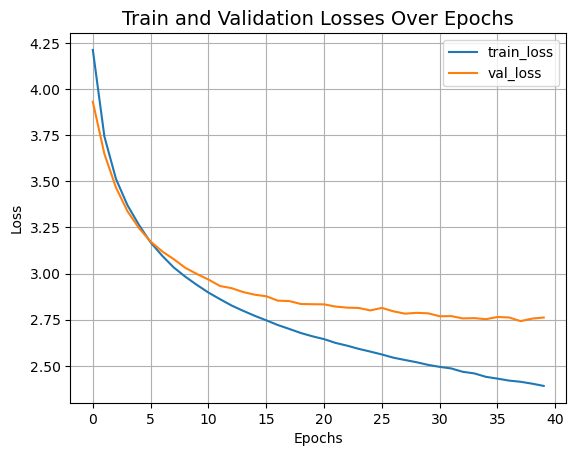

In [44]:
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train and Validation Losses Over Epochs", fontsize=14)
plt.legend()
plt.grid()
plt.show()

loss, accuracy, top_5_accuracy = model.evaluate(x_test, y_test, verbose=1)
print(f"Test loss: {round(loss, 2)}")
print(f"Test accuracy: {round(accuracy * 100, 2)}%")
print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

Let's display the final results of the training on CIFAR-100.

In [45]:
loss, accuracy, top_5_accuracy = model.evaluate(dataset_test)
print(f"Test loss: {round(loss, 2)}")
print(f"Test accuracy: {round(accuracy * 100, 2)}%")
print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

40/40 [==============================] - 0s 12ms/step - loss: 2.6953 - accuracy: 0.4424 - top-5-accuracy: 0.7494
Test loss: 2.7
Test accuracy: 44.24%
Test top 5 accuracy: 74.94%


The Swin Transformer model we just trained has just 152K parameters, and it gets
us to ~75% test top-5 accuracy within just 40 epochs without any signs of
overfitting as well as seen in above graph. This means we can train this network
for longer (perhaps with a bit more regularization) and obtain even better
performance. This performance can further be improved by additional techniques
like cosine decay learning rate schedule, other data augmentation techniques.
By training the model for 150 epochs with a slightly
higher dropout and greater embedding dimensions, we can push the performance to
~72% test accuracy on CIFAR-100 as you can see in the screenshot.

![Results of training for longer](https://i.imgur.com/9vnQesZ.png)